In [1]:
# Import the necessary Libraries
import os
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image
from dotenv import load_dotenv
import os
load_dotenv()
os.environ["GROK_API_KEY"] = os.getenv('GROK_API_KEY')

In [2]:
# We'll define the state that our agent will maintain throughout its operation.
from typing import TypedDict

class PlannerState(TypedDict):
    messages: Annotated[List[HumanMessage | AIMessage], "The messages in the conversation"]
    city: str
    interests: List[str]
    itinerary: str

In [4]:
from langchain_groq.chat_models import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b", api_key=os.getenv("GROK_API_KEY"))


itinerary_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful travel assistant. Create a day trip itinerary for {city} based on the user's interests: {interests}. Provide a brief, bulleted itinerary."),
    ("human", "Create an itinerary for my day trip."),
])

In [8]:
print(itinerary_prompt)

input_variables=['city', 'interests'] input_types={} partial_variables={} messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['city', 'interests'], input_types={}, partial_variables={}, template="You are a helpful travel assistant. Create a day trip itinerary for {city} based on the user's interests: {interests}. Provide a brief, bulleted itinerary."), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='Create an itinerary for my day trip.'), additional_kwargs={})]


In [9]:
# Now we'll define the main functions that our agent will use: get city, get interests, create itinerary

def input_city(state: PlannerState) -> PlannerState:
    print("Please enter the city you want to visit for your day trip:")
    user_message = input("Your input: ")
    return {
        **state,
        "city": user_message,
        "messages": state['messages'] + [HumanMessage(content=user_message)],
    }

def input_interests(state: PlannerState) -> PlannerState:
    print(f"Please enter your interests for the trip to {state['city']} (comma-separated):")
    user_message = input("Your input: ")
    return {
        **state,
        "interests": [interest.strip() for interest in user_message.split(',')],
        "messages": state['messages'] + [HumanMessage(content=user_message)],
    }

def create_itinerary(state: PlannerState) -> PlannerState:
    print(f"Creating an itinerary for {state['city']} based on interests: {', '.join(state['interests'])}...")
    response = llm.invoke(itinerary_prompt.format_messages(city=state['city'], interests=", ".join(state['interests'])))
    print("\nFinal Itinerary:")
    print(response.content)
    return {
        **state,
        "messages": state['messages'] + [AIMessage(content=response.content)],
        "itinerary": response.content,
    }

In [10]:
# Now we'll create our LangGraph workflow and compile it.

workflow = StateGraph(PlannerState)

workflow.add_node("input_city", input_city)
workflow.add_node("input_interests", input_interests)
workflow.add_node("create_itinerary", create_itinerary)

workflow.set_entry_point("input_city")

workflow.add_edge("input_city", "input_interests")
workflow.add_edge("input_interests", "create_itinerary")
workflow.add_edge("create_itinerary", END)

app = workflow.compile()

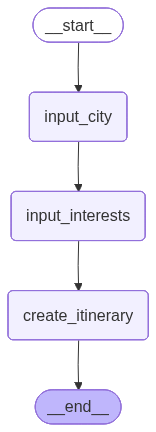

In [11]:
# Display the graph structure
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [ ]:
# Define the function that runs the graph

def run_travel_planner(user_request: str):
    print(f"Initial Request: {user_request}\n")
    state = {
        "messages": [HumanMessage(content=user_request)],
        "city": "",
        "interests": [],
        "itinerary": "",
    }
    
    for output in app.stream(state):
        pass  # The nodes themselves now handle all printing

In [16]:
# Use case example

user_request = "I want to plan a day trip."
run_travel_planner(user_request)

Initial Request: I want to plan a day trip.

Please enter the city you want to visit for your day trip:
Please enter your interests for the trip to   (comma-separated):
Creating an itinerary for   based on interests: , , , , , , , , , , , , , , , , , ...

Final Itinerary:
<think>
Okay, the user wants a day trip itinerary. They mentioned they're a helpful travel assistant, so I need to make sure the plan is efficient and covers interesting places. Let me start by checking if there are any specific interests listed. The user's interests are listed as a bunch of commas, but there's nothing after them. Hmm, maybe they forgot to add their preferences. Without knowing their interests, it's hard to tailor the trip. I should ask for more details.

Wait, the initial message has "Create a day trip itinerary for based on the user's interests: , , , , , , , , , , , , , , , , , . Provide a brief, bulleted itinerary." So the user's interests are missing. That's a problem. How can I create a personal